In [1]:
from pathlib import Path
import xarray as xr
import ecco_v4_py as ecco
from xgcm import Grid
import gsw
import matplotlib.pyplot as plt
import cmocean
import numpy as np
from scipy.interpolate import interp1d
from scipy import optimize
import pandas as pd
import matplotlib.dates as mdates
from os.path import join,expanduser,exists,split
import glob

In [2]:
import warnings
warnings.filterwarnings("ignore")

#### **Load the desired variables and define grid/metrics**

In [4]:
# v4r4
ECCO_version = 'v4r4'
ECCO_dir = Path.home() / 'share_disk3/ECCO_products/Version4/Release4'
grid_file_path = glob.glob(join(ECCO_dir,'*GEOMETRY*','*GEOMETRY*.nc'))[0]
TS_file_paths           = join(ECCO_dir,'*TEMP_SALINITY*MONTHLY*',f'*.nc')
ML_file_paths           = join(ECCO_dir,'nctiles_monthly','MXLDEPTH','*',f'*.nc')


In [5]:
## Load the model grid
ecco_grid = xr.open_mfdataset(grid_file_path,\
                              chunks={'k':50,'tile':13,'j':90,'j_g':90,'i':90,'i_g':90})

In [6]:
## Create a dataset of monthly advective and diffusive temperature fluxes, 1992-2017
ecco_vars_ml = xr.open_mfdataset(ML_file_paths,\
                              chunks={'k':50,'tile':13,'j':90,'j_g':90,'i':90,'i_g':90},\
                              parallel=True,data_vars='minimal',coords='minimal',compat='override')

OSError: no files to open

In [ ]:
## Merge the ecco_grid with the ecco_vars to make the ecco_ds
ecco_ds = xr.merge((ecco_grid , ecco_vars_ml),compat='override')

In [ ]:
# define the metrics
ecco_ds['drW'] = ecco_ds.hFacW * ecco_ds.drF #vertical cell size at u point
ecco_ds['drS'] = ecco_ds.hFacS * ecco_ds.drF #vertical cell size at v point
ecco_ds['drV'] = ecco_ds.rA * ecco_ds.drF # volume at centre and k
ecco_ds['drVg'] = ecco_ds.rAz * ecco_ds.drF # volume at q and k
ecco_ds['drVw'] = ecco_ds.rAw * ecco_ds.drF # volume at q and k
ecco_ds['drVs'] = ecco_ds.rAs * ecco_ds.drF # volume at q and k

metrics = { ('X',): ['dxC', 'dxG'], # X distances
    ('Y',): ['dyC', 'dyG'], # Y distances
    ('Z',): ['drW', 'drS', 'drC','drF'], # Z distances
    ('X', 'Y'): ['rA', 'rAz', 'rAs', 'rAw'], #Areas
    ('X', 'Y','Z'): ['drV','drVg','drVs','drVw']} #volumes

grid = Grid(ecco_ds,periodic=False, metrics=metrics)

In [ ]:
surface_area = grid.integrate(ecco_ds.maskC.isel(k=0), ['X', 'Y']).sum('tile')
mean_mld = grid.integrate(ecco_ds.MXLDEPTH, ['X','Y']).sum('tile') / surface_area

In [ ]:
mean_mld.plot()

In [ ]:
print(ECCO_version,'mean MLD = ',mean_mld.mean('time').values,' m')

In [8]:
## v4r5
ECCO_version = 'v4r5'
ECCO_grid = Path.home() / 'share_disk3/ECCO_products/Version4/Release5/netcdf/native/grid/'
ECCO_dir = Path.home() / 'share_disk3/ECCO_products/Version4/Release5/netcdf/native/monthly/'
grid_file_path = glob.glob(join(ECCO_grid,'*GEOMETRY*.nc'))[0]
TS_file_paths           = join(ECCO_dir,'*TEMPERATURE_SALINITY',f'*.nc')
ML_file_paths           = join(ECCO_dir,'*MIXED_LAYER_DEPTH',f'*.nc')

In [9]:
## Load the model grid
ecco_grid = xr.open_mfdataset(grid_file_path,\
                              chunks={'k':50,'tile':13,'j':90,'j_g':90,'i':90,'i_g':90})

In [10]:
## Create a dataset of monthly advective and diffusive temperature fluxes, 1992-2017
ecco_vars_ml = xr.open_mfdataset(ML_file_paths,\
                              chunks={'k':50,'tile':13,'j':90,'j_g':90,'i':90,'i_g':90},\
                              parallel=True,data_vars='minimal',coords='minimal',compat='override')

In [11]:
## Merge the ecco_grid with the ecco_vars to make the ecco_ds
ecco_ds = xr.merge((ecco_grid , ecco_vars_ml),compat='override')

In [12]:
# define the metrics
ecco_ds['drW'] = ecco_ds.hFacW * ecco_ds.drF #vertical cell size at u point
ecco_ds['drS'] = ecco_ds.hFacS * ecco_ds.drF #vertical cell size at v point
ecco_ds['drV'] = ecco_ds.rA * ecco_ds.drF # volume at centre and k
ecco_ds['drVg'] = ecco_ds.rAz * ecco_ds.drF # volume at q and k
ecco_ds['drVw'] = ecco_ds.rAw * ecco_ds.drF # volume at q and k
ecco_ds['drVs'] = ecco_ds.rAs * ecco_ds.drF # volume at q and k

metrics = { ('X',): ['dxC', 'dxG'], # X distances
    ('Y',): ['dyC', 'dyG'], # Y distances
    ('Z',): ['drW', 'drS', 'drC','drF'], # Z distances
    ('X', 'Y'): ['rA', 'rAz', 'rAs', 'rAw'], #Areas
    ('X', 'Y','Z'): ['drV','drVg','drVs','drVw']} #volumes

grid = Grid(ecco_ds,periodic=False, metrics=metrics)

In [13]:
surface_area = grid.integrate(ecco_ds.maskC.isel(k=0), ['X', 'Y']).sum('tile')
mean_mld = grid.integrate(ecco_ds.MXLDEPTH, ['X','Y']).sum('tile') / surface_area

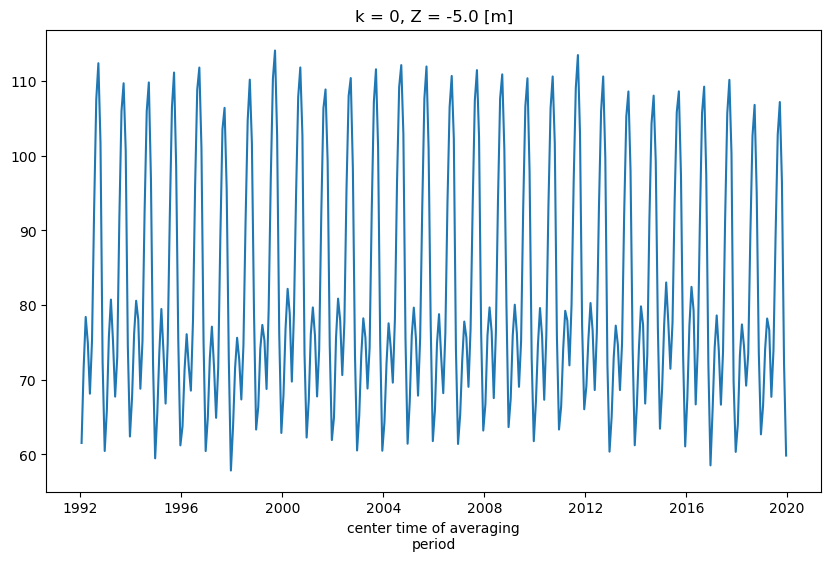

In [14]:
mean_mld.plot()

In [15]:
print(ECCO_version,'mean MLD = ',mean_mld.mean('time').values,' m')

v4r5 mean MLD =  82.06358  m
